In [4]:
# Cell 2: Load trained MulCLIP model & display top-10 retrieved captions for a query image

import torch
import sys
import os
from types import SimpleNamespace
from torch.utils.data import DataLoader
from IPython.display import display
from PIL import Image
import numpy as np

# thêm import
sys.path.append("..")
from model import longclip
from train import CLIP_Clean_Train
from dci import JsonDCIDataset

# 1) Load trainer và checkpoint
args = SimpleNamespace(
    base_model='ViT-B/16',
    download_root=None,
    log_scale=4.6052,
    batch_size=64,
    epochs=1,
    lr=1e-5,
    refine_lr_image=2e-6,
    refine_lr_text=2e-4,
    weight_decay=0.01,
    warmup_length=200,
    exp_name='eval_run',
    ckpt_path="/home/ubuntu/shared/chau.thv/sd_weigth/nips/1105/dci_aux_B-64_lr=1e-05_wd=0.05_refineI=0.0002_refineT=0.0002_batch=64_wl=200_logs=4.6052_64xb/ckpt/ddp-epoch7-05-11--16_39_55.pt"
)
trainer = CLIP_Clean_Train(args)
state = torch.load(args.ckpt_path, map_location='cpu')
trainer.model.load_state_dict(state, strict=False)

# Extract core model (xử lý DDP), đưa về eval mode
model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device).eval()

# 2) Prepare DataLoader (dataset gốc dùng preprocess tương tự để encode text)
test_ds = JsonDCIDataset(
    json_path="/home/ubuntu/hieu.tq/Git/GOAL/datasets/DCI_test.json",
    max_items=None
)
test_loader = DataLoader(test_ds, batch_size=args.batch_size, shuffle=False, num_workers=4)

# 3) Precompute tất cả text features + lưu caption strings
txt_feats = []
captions = []
with torch.no_grad():
    for _, text_list, _, _, _ in test_loader:
        # text_list: list of string captions
        tokens = longclip.tokenize(text_list, truncate=True).to(device)
        feats, _ = model.encode_text(tokens)    # [B, D]
        feats = feats / feats.norm(dim=-1, keepdim=True)
        txt_feats.append(feats)
        captions.extend(text_list)

txt_feats_all = torch.cat(txt_feats, dim=0)   # [M, D]

# 4) Hàm retrieve ảnh → captions
def retrieve_and_display_captions(image_path: str, gt_caption: str = None, topk: int = 10, max_img_width: int = 300):
    """
    Cho 1 ảnh, tìm top-k captions có similarity cao nhất;
    Hiển thị ảnh và in ra các caption kèm similarity score,
    highlight caption GT nếu có.
    """
    # Load & preprocess image bằng transform của dataset
    img = Image.open(image_path).convert("RGB")
    transform = test_ds.transform   # transform mặc định của JsonDCIDataset
    image_input = transform(img).unsqueeze(0).to(device)

    # encode image
    with torch.no_grad():
        img_feat, _ = model.encode_image(image_input)  # [1, D]
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)

    # tính similarity với tất cả text_feats
    sims = img_feat @ txt_feats_all.T                 # [1, M]
    values, indices = sims.topk(topk, dim=-1)         #  top-k
    scores = values[0].cpu().tolist()
    idxs   = indices[0].cpu().tolist()

    # Hiển thị ảnh gốc (resize cho vừa màn hình)
    w0, h0 = img.size
    new_w = max_img_width
    new_h = int(h0 * new_w / w0)
    display(img.resize((new_w, new_h)))

    # In top-k captions
    print(f"Top-{topk} captions for {os.path.basename(image_path)}:\n")
    for rank, (score, idx) in enumerate(zip(scores, idxs), start=1):
        cap = captions[idx]
        prefix = ">> " if (gt_caption is not None and cap == gt_caption) else "   "
        print(f"{prefix}{rank:2d}. [{score:.3f}] {cap}")

# Ví dụ sử dụng:
# retrieve_and_display_captions(
#    "/home/ubuntu/hieu.tq/Git/GOAL/images/123.jpg",
#    gt_caption="a man riding a bicycle on a city street", 
#    topk=10
# )


# test

In [1]:
# Cell 1: Load dataset, chuẩn bị DataLoader và random 10 caption kèm đường dẫn ảnh
import random
from torch.utils.data import DataLoader, Dataset
import torch
import clip
import os
from PIL import Image

class Urban1kDataset(Dataset):
    """
    Dataset for Urban1k: trả về (image_tensor, caption, _, img_path, _)
    """
    def __init__(self, root_dir, max_items=None, device='cuda'):
        self.image_dir   = os.path.join(root_dir, 'image')
        self.caption_dir = os.path.join(root_dir, 'caption')
        self.ids = sorted(
            fname[:-4] for fname in os.listdir(self.caption_dir) if fname.endswith('.txt')
        )
        if max_items:
            self.ids = self.ids[:max_items]
        self.device = torch.device(device)
        _, self.preprocess = clip.load('ViT-B/16', device=self.device)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        _id = self.ids[idx]
        # Load caption
        cap_path = os.path.join(self.caption_dir, f'{_id}.txt')
        caption = open(cap_path, 'r', encoding='utf8').read().strip().replace('\n', ' ')
        # Load & preprocess image
        img_path = os.path.join(self.image_dir, f'{_id}.jpg')
        image = Image.open(img_path).convert('RGB')
        image_t = self.preprocess(image)
        return image_t, caption, "None", img_path, "None"

/home/ubuntu/miniconda3/envs/kdpl/lib/python3.8/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
# # Cell 2: Load trained MulCLIP model & display top-10 retrieved captions for a query image

# import torch
# import sys
# import os
# from types import SimpleNamespace
# from torch.utils.data import DataLoader
# from IPython.display import display
# from PIL import Image
# import numpy as np

# # thêm import
# from model import longclip
# from train import CLIP_Clean_Train
# from dci import JsonDCIDataset

# # 1) Load trainer và checkpoint
# args = SimpleNamespace(
#     base_model='ViT-B/16',
#     download_root=None,
#     log_scale=4.6052,
#     batch_size=64,
#     epochs=1,
#     lr=1e-5,
#     refine_lr_image=2e-6,
#     refine_lr_text=2e-4,
#     weight_decay=0.01,
#     warmup_length=200,
#     exp_name='eval_run',
#     ckpt_path="/home/ubuntu/shared/chau.thv/sd_weigth/nips/1105/dci_aux_B-64_lr=1e-05_wd=0.05_refineI=0.0002_refineT=0.0002_batch=64_wl=200_logs=4.6052_64xb/ckpt/ddp-epoch7-05-11--16_39_55.pt"
# )
# trainer = CLIP_Clean_Train(args)
# state = torch.load(args.ckpt_path, map_location='cpu')
# trainer.model.load_state_dict(state, strict=False)

# # Extract core model (xử lý DDP), đưa về eval mode
# model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = model.to(device).eval()

# # 2) Prepare DataLoader (dataset gốc dùng preprocess tương tự để encode text)
# test_ds = JsonDCIDataset(
#     json_path="/home/ubuntu/chau.thv/Git/GOAL/datasets/DCI_test.json",
#     max_items=None
# )
# test_loader = DataLoader(test_ds, batch_size=args.batch_size, shuffle=False, num_workers=4)

# # 3) Precompute tất cả text features + lưu caption strings
# txt_feats = []
# captions = []
# with torch.no_grad():
#     for _, text_list, _, _, _ in test_loader:
#         # text_list: list of string captions
#         tokens = longclip.tokenize(text_list, truncate=True).to(device)
#         feats, _ = model.encode_text(tokens)    # [B, D]
#         feats = feats / feats.norm(dim=-1, keepdim=True)
#         txt_feats.append(feats)
#         captions.extend(text_list)

# txt_feats_all = torch.cat(txt_feats, dim=0)   # [M, D]

# # 4) Hàm retrieve ảnh → captions
# def retrieve_and_display_captions(image_path: str, gt_caption: str = None, topk: int = 10, max_img_width: int = 300):
#     """
#     Cho 1 ảnh, tìm top-k captions có similarity cao nhất;
#     Hiển thị ảnh và in ra các caption kèm similarity score,
#     highlight caption GT nếu có.
#     """
#     # Load & preprocess image bằng transform của dataset
#     img = Image.open(image_path).convert("RGB")
#     transform = test_ds.transform   # transform mặc định của JsonDCIDataset
#     image_input = transform(img).unsqueeze(0).to(device)

#     # encode image
#     with torch.no_grad():
#         img_feat, _ = model.encode_image(image_input)  # [1, D]
#         img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)

#     # tính similarity với tất cả text_feats
#     sims = img_feat @ txt_feats_all.T                 # [1, M]
#     values, indices = sims.topk(topk, dim=-1)         #  top-k
#     scores = values[0].cpu().tolist()
#     idxs   = indices[0].cpu().tolist()

#     # Hiển thị ảnh gốc (resize cho vừa màn hình)
#     w0, h0 = img.size
#     new_w = max_img_width
#     new_h = int(h0 * new_w / w0)
#     display(img.resize((new_w, new_h)))

#     # In top-k captions
#     print(f"Top-{topk} captions for {os.path.basename(image_path)}:\n")
#     for rank, (score, idx) in enumerate(zip(scores, idxs), start=1):
#         cap = captions[idx]
#         prefix = ">> " if (gt_caption is not None and cap == gt_caption) else "   "
#         print(f"{prefix}{rank:2d}. [{score:.3f}] {cap}")

# # Ví dụ sử dụng:
# # retrieve_and_display_captions(
# #    "/home/ubuntu/hieu.tq/Git/GOAL/images/123.jpg",
# #    gt_caption="a man riding a bicycle on a city street", 
# #    topk=10
# # )


In [14]:
# Cell 2: Load trained MulCLIP model & perform image-to-text retrieval

import torch
import sys
import os
import random
from types import SimpleNamespace
from torch.utils.data import DataLoader
from PIL import Image
import clip  # chỉ để load preprocess nếu cần
sys.path.append("..")
from model import longclip
from train import CLIP_Clean_Train

# 1) Load trainer và checkpoint
args = SimpleNamespace(
    base_model='ViT-B/16',
    download_root=None,
    log_scale=4.6052,
    batch_size=64,
    epochs=1,
    lr=1e-5,
    refine_lr_image=2e-6,
    refine_lr_text=2e-4,
    weight_decay=0.01,
    warmup_length=200,
    exp_name='eval_run',
    ckpt_path="/home/ubuntu/shared/chau.thv/sd_weigth/longclip/dci_b16_siglip_3loss_1GPU_lr=1e-05_wd=0.05_refineI=0.0002_refineT=0.0002_batch=16_wl=200_logs=4.6052_64xb/ckpt/Propose-b16-longclip-epoch7-05-14--12_25_32_-local05_2for_tau007.pt"
)
trainer = CLIP_Clean_Train(args)
state = torch.load(args.ckpt_path, map_location='cpu')
trainer.model.load_state_dict(state, strict=False)
model = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device).eval()

# 2) Prepare DataLoader
data_root = '/home/ubuntu/shared/hieu.tq/Urban1k/Urban1k'
test_ds = Urban1kDataset(data_root, max_items=None, device=device)
test_loader = DataLoader(test_ds, batch_size=args.batch_size, shuffle=False, num_workers=4)

# 3) Precompute text features và captions
text_feats, captions = [], []
with torch.no_grad():
    for _, caps, _, _, _ in test_loader:
        tokens = longclip.tokenize(caps, truncate=True).to(device)
        feats, _ = model.encode_text(tokens)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        text_feats.append(feats)
        captions.extend(caps)
text_feats_all = torch.cat(text_feats, dim=0)  # [N_captions, D]

# def retrieve_and_display_texts(image_path: str, gt_caption: str, topk: int = 10):
#     """
#     Lấy top-k captions cho ảnh image_path, in similarity score,
#     highlight caption gốc nếu trùng.
#     """
#     # Load & preprocess ảnh
#     image = Image.open(image_path).convert("RGB")
#     image_t = test_ds.preprocess(image).unsqueeze(0).to(device)

#     # Encode image
#     with torch.no_grad():
#         img_feat, _ = model.encode_image(image_t)
#         img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
#         sims = img_feat @ text_feats_all.T  # [1, N_captions]
#         values, indices = sims.topk(topk, dim=-1)

#     scores = values[0].tolist()
#     idxs   = indices[0].tolist()

#     # In kết quả
#     for rank, (idx, score) in enumerate(zip(idxs, scores), 1):
#         cap = captions[idx]
#         flag = "GT --> " if cap == gt_caption else ""
#         print(f"{flag}{rank:2d}. [{score:.3f}] {cap}")

from PIL import Image
from IPython.display import display

def retrieve_and_display_texts(image_path: str, gt_caption: str, topk: int = 10, max_size: int = 400):
    """
    - Load & resize ảnh (max max_size x max_size) rồi display.
    - Lấy top-k captions, in similarity score và highlight caption gốc nếu trùng.
    """
    # 1) Load ảnh và resize
    image = Image.open(image_path).convert("RGB")
    image.thumbnail((max_size, max_size), Image.LANCZOS)
    display(image)

    # 2) Preprocess & encode
    image_t = test_ds.preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        img_feat, _ = model.encode_image(image_t)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        sims = img_feat @ text_feats_all.T        # [1, N_captions]
        values, indices = sims.topk(topk, dim=-1)

    scores = values[0].tolist()
    idxs   = indices[0].tolist()

    # 3) In kết quả
    print("\nTop-{} captions:".format(topk))
    for rank, (idx, score) in enumerate(zip(idxs, scores), 1):
        cap = captions[idx]
        flag = "✅ GT" if cap == gt_caption else ""
        print(f"{flag}{rank:2d}. [{score:.3f}] {cap}")




In [15]:
# from PIL import Image
# from IPython.display import display

# def retrieve_and_display_texts(image_path: str, gt_caption: str, topk: int = 10, max_size: int = 400):
#     """
#     - Load & resize ảnh (max max_size x max_size) rồi display.
#     - Lấy top-k captions, in similarity score và highlight caption gốc nếu trùng.
#     """
#     # 1) Load ảnh và resize
#     image = Image.open(image_path).convert("RGB")
#     image.thumbnail((max_size, max_size), Image.LANCZOS)
#     display(image)

#     # 2) Preprocess & encode
#     image_t = test_ds.preprocess(image).unsqueeze(0).to(device)
#     with torch.no_grad():
#         img_feat, _ = model.encode_image(image_t)
#         img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
#         sims = img_feat @ text_feats_all.T        # [1, N_captions]
#         values, indices = sims.topk(topk, dim=-1)

#     scores = values[0].tolist()
#     idxs   = indices[0].tolist()

#     # 3) In kết quả
#     print("\nTop-{} captions:".format(topk))
#     for rank, (idx, score) in enumerate(zip(idxs, scores), 1):
#         cap = captions[idx]
#         flag = "GT --> " if cap == gt_caption else ""
#         print(f"{flag}{rank:2d}. [{score:.3f}] {cap}")


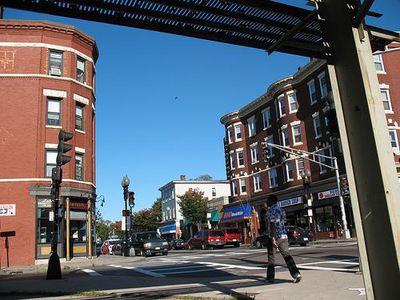


Top-10 captions:
✅ GT 1. [0.141] This image depicts a vibrant urban street corner on a clear day with blue skies. A person in a blue checkered shirt and casual pants crosses the road at a pedestrian crosswalk, heading towards a series of red brick buildings with rounded and straight corners. The architecture suggests a charming, historic neighborhood with storefronts on the ground level, including one with a blue awning. There's a green streetlight visible and a black lamp post, adding to the quaint ambiance. Vehicles are stopped at the intersection, and the scene includes an overhanging metal structure that could be part of a bus stop. The overall atmosphere is that of a peaceful, sunny day in a bustling city neighborhood.
 2. [0.128] The image shows an urban street intersection with vehicular and pedestrian activity. In the foreground, there's a pedestrian crossing the street marked with white zebra lines and a black car in the middle of the crosswalk. The traffic light for pedestri

In [16]:
# Example usage:
IMAGE_PATH     = "/home/ubuntu/shared/hieu.tq/Urban1k/Urban1k/image/46.jpg"
GT_CAPTION     = "This image depicts a vibrant urban street corner on a clear day with blue skies. A person in a blue checkered shirt and casual pants crosses the road at a pedestrian crosswalk, heading towards a series of red brick buildings with rounded and straight corners. The architecture suggests a charming, historic neighborhood with storefronts on the ground level, including one with a blue awning. There's a green streetlight visible and a black lamp post, adding to the quaint ambiance. Vehicles are stopped at the intersection, and the scene includes an overhanging metal structure that could be part of a bus stop. The overall atmosphere is that of a peaceful, sunny day in a bustling city neighborhood."
retrieve_and_display_texts(IMAGE_PATH, GT_CAPTION)

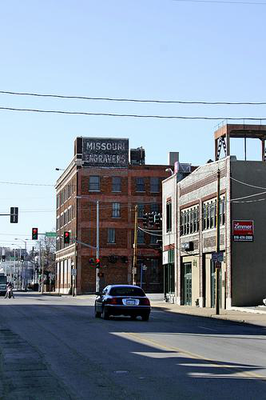


Top-10 captions:
✅ GT 1. [0.139] The image shows an urban street scene under a clear blue sky. In the foreground, a black car is driving down the road, which is lined with electrical wires above. The architecture is a mix of multi-story brick buildings with visible signs of wear and faded paint, suggesting a historical urban area. The buildings vary in height, with some having flat facades and others featuring recessed windows and ornate detailing. The street appears to be relatively empty, with no pedestrians visible and minimal vehicular traffic. The structures' color palette is predominantly red brick, with accents of tan and white on the secondary building elements.
 2. [0.115] The image shows an urban street corner on a sunny day, with red brick pavement and a black sedan stopped at a traffic light. A green street sign reads "DE LAFAYETTE" at the top, and underneath, there's a sign indicating "Washington St." with arrows pointing in both directions. Traffic signals are visible, w

In [17]:
# Example usage:
IMAGE_PATH     = "/home/ubuntu/shared/hieu.tq/Urban1k/Urban1k/image/7.jpg"
GT_CAPTION     = "The image shows an urban street scene under a clear blue sky. In the foreground, a black car is driving down the road, which is lined with electrical wires above. The architecture is a mix of multi-story brick buildings with visible signs of wear and faded paint, suggesting a historical urban area. The buildings vary in height, with some having flat facades and others featuring recessed windows and ornate detailing. The street appears to be relatively empty, with no pedestrians visible and minimal vehicular traffic. The structures' color palette is predominantly red brick, with accents of tan and white on the secondary building elements."
retrieve_and_display_texts(IMAGE_PATH, GT_CAPTION)

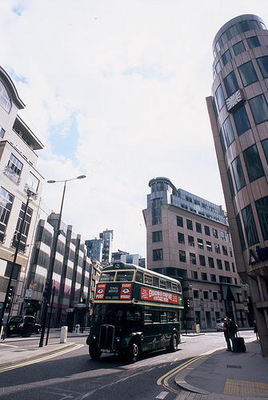


Top-10 captions:
 1. [0.243] This image captures an urban street scene featuring a classic red double-decker bus in the right foreground, indicating a location likely in the United Kingdom, possibly London. The bus displays a destination sign, suggesting it is in service. Multi-story buildings flank both sides of the street with a mix of brick facades and large windows, typical of urban architecture in the area. The road is marked with white lines, indicating traffic lanes, and there appears to be a clear sky above, suggesting good weather conditions. Visible adverts on the bus and building exteriors suggest commercial activity in the area.
 2. [0.214] This image captures a British urban scene, highlighted by a classic red double-decker bus on the right, displaying route number 30. The bus has yellow text and advertisements printed on its sides. On the left, a pedestrian wearing a green jacket and carrying a bag seems to be briskly walking on the sidewalk. There's a yellow street sign

In [7]:
# Example usage:
IMAGE_PATH     = "/home/ubuntu/shared/hieu.tq/Urban1k/Urban1k/image/23.jpg"
GT_CAPTION     = "The image presents a classic double-decker bus driving on a city road under a bright blue sky with scattered clouds. The bus is painted in a dark hue, likely a traditional green or black, and features advertisements on its sides. The surrounding architecture is a mix of modern and older styles. To the right of the bus, a cylindrical building with a reflective glass facade towers over the street, while more conventional buildings with straight lines and rectangular windows line the left-hand side. There is a pedestrian visible on the sidewalk, and another smaller vehicle, which appears to be a motorcycle, follows the bus on the road. The environment suggests an urban setting, possibly in a European city. Shadows on the road indicate the sun is shining from a high angle, suggesting the time of day could be around noon."
retrieve_and_display_texts(IMAGE_PATH, GT_CAPTION)

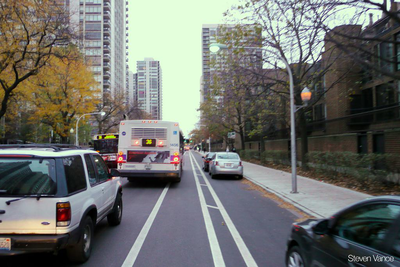


Top-10 captions:
 1. [0.154] This image shows a daytime street scene captured from the perspective of a driver in a vehicle. In the foreground, there is the rear of a dark-colored Chevrolet truck on the left, with its brake lights illuminated. To the right is the back of a maroon sedan with a Chevrolet logo. The vehicles appear to be stopped in traffic. In the middle ground, a bright yellow school bus is visible with the words "SCHOOL BUS" printed in black on its rear. There are flashing lights visible on the bus, suggesting it may be stopped or in the process of stopping. In the background beyond the school bus, traffic lights and other vehicles are partially visible, indicating an urban setting. The weather seems to be clear, and daylight is evident from the brightness outside.
✅ GT 2. [0.136] This image captures an urban street scene with tall residential buildings lining one side and leafy trees displaying autumn colors. The scene includes a city bus in the center of the frame, sh

In [18]:
# Example usage:
IMAGE_PATH     = "/home/ubuntu/shared/hieu.tq/Urban1k/Urban1k/image/50.jpg"
GT_CAPTION     = "This image captures an urban street scene with tall residential buildings lining one side and leafy trees displaying autumn colors. The scene includes a city bus in the center of the frame, showing the number 36 on its indicator, and various other vehicles such as cars and SUVs. The road features a dedicated bike lane on the right, demarcated by white lines and identified by painted bicycle symbols. The overcast sky and the presence of a streetlight that is turned on suggest that this is either early morning or late afternoon. The photo appears to be taken from the perspective of a pedestrian or cyclist at street level, focused on capturing the flow of urban traffic."
retrieve_and_display_texts(IMAGE_PATH, GT_CAPTION)

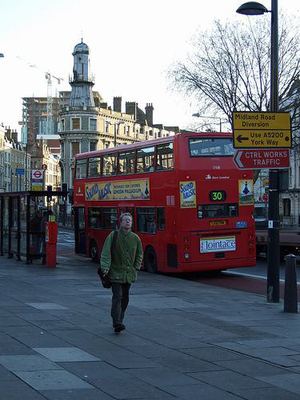


Top-10 captions:
✅ GT 1. [0.203] This image captures a British urban scene, highlighted by a classic red double-decker bus on the right, displaying route number 30. The bus has yellow text and advertisements printed on its sides. On the left, a pedestrian wearing a green jacket and carrying a bag seems to be briskly walking on the sidewalk. There's a yellow street sign indicating a diversion ahead. In the background, an ornate building towers with a clock at its apex under a clear blue sky. The street is flanked by various other buildings, likely a mix of residential and commercial structures, typical of a UK cityscape.
 2. [0.160] This image captures an urban street scene featuring a classic red double-decker bus in the right foreground, indicating a location likely in the United Kingdom, possibly London. The bus displays a destination sign, suggesting it is in service. Multi-story buildings flank both sides of the street with a mix of brick facades and large windows, typical of urba

In [19]:
# Example usage:
IMAGE_PATH     = "/home/ubuntu/shared/hieu.tq/Urban1k/Urban1k/image/208.jpg"
GT_CAPTION     = "This image captures a British urban scene, highlighted by a classic red double-decker bus on the right, displaying route number 30. The bus has yellow text and advertisements printed on its sides. On the left, a pedestrian wearing a green jacket and carrying a bag seems to be briskly walking on the sidewalk. There's a yellow street sign indicating a diversion ahead. In the background, an ornate building towers with a clock at its apex under a clear blue sky. The street is flanked by various other buildings, likely a mix of residential and commercial structures, typical of a UK cityscape."
retrieve_and_display_texts(IMAGE_PATH, GT_CAPTION)

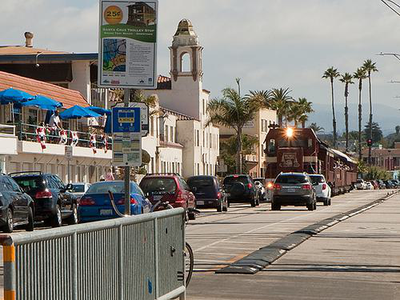


Top-10 captions:
✅ GT 1. [0.100] This image captures a sunny urban street scene with vehicles parked along the right side and a clear sky above. On the left, a building with a balcony adorned with American flags and blue umbrellas suggests a restaurant or cafe. A tall structure with a bell tower shape is visible further down, indicating historical or religious significance. Palm trees line the horizon alongside other greenery, providing a tropical ambiance. A metallic guard rail runs parallel to the sidewalk in the foreground, while a utility pole with signage stands prominently at the front. The overall architecture showcases a mix of commercial and possibly Spanish colonial styles.
 2. [0.093] The image depicts an overcast day on a suburban street with a mix of parked and moving vehicles. The road appears calm with light traffic, featuring predominantly red and white cars. There's a pedestrian crossing ahead, marked by yellow pedestrian crossing signs on both sides of the street. Ov

In [20]:
# Example usage:
IMAGE_PATH     = "/home/ubuntu/shared/hieu.tq/Urban1k/Urban1k/image/232.jpg"
GT_CAPTION     = "This image captures a sunny urban street scene with vehicles parked along the right side and a clear sky above. On the left, a building with a balcony adorned with American flags and blue umbrellas suggests a restaurant or cafe. A tall structure with a bell tower shape is visible further down, indicating historical or religious significance. Palm trees line the horizon alongside other greenery, providing a tropical ambiance. A metallic guard rail runs parallel to the sidewalk in the foreground, while a utility pole with signage stands prominently at the front. The overall architecture showcases a mix of commercial and possibly Spanish colonial styles."
retrieve_and_display_texts(IMAGE_PATH, GT_CAPTION)

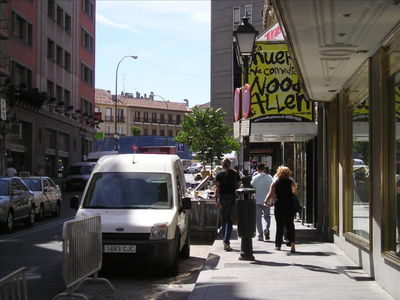


Top-10 captions:
✅ GT 1. [0.129] This image captures a busy urban street scene on a sunny day. The foreground shows a white van parked on the side of the road with a visible license plate. Pedestrians can be seen walking along a wide sidewalk lined with buildings and shops, one featuring a bright awning and signage possibly advertising a theater with a performance or film related to Woody Allen. Traffic signs, other parked cars, street lamps, and a steel barrier also occupy the sidewalk space. The architecture of the buildings suggests a European cityscape, while scattered foliage and a blue sky indicate pleasant weather.
 2. [0.108] The image captures an urban scene on a sunny day with a two-story building displaying the street number 147 on its façade. A white delivery truck covered in graffiti is parked in front of the building. Its prominent graffiti reads "OMG" in large, black letters. There's a red car visible in front of the truck. On the building's ground level, there are stor

In [21]:
# Example usage:
IMAGE_PATH     = "/home/ubuntu/shared/hieu.tq/Urban1k/Urban1k/image/246.jpg"
GT_CAPTION     = "This image captures a busy urban street scene on a sunny day. The foreground shows a white van parked on the side of the road with a visible license plate. Pedestrians can be seen walking along a wide sidewalk lined with buildings and shops, one featuring a bright awning and signage possibly advertising a theater with a performance or film related to Woody Allen. Traffic signs, other parked cars, street lamps, and a steel barrier also occupy the sidewalk space. The architecture of the buildings suggests a European cityscape, while scattered foliage and a blue sky indicate pleasant weather."
retrieve_and_display_texts(IMAGE_PATH, GT_CAPTION)